In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

diabetes_data = pd.read_csv('diabetes.csv')
print(diabetes_data['Outcome'].value_counts())
diabetes_data.head(3)

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


<Axes: xlabel='Outcome', ylabel='count'>

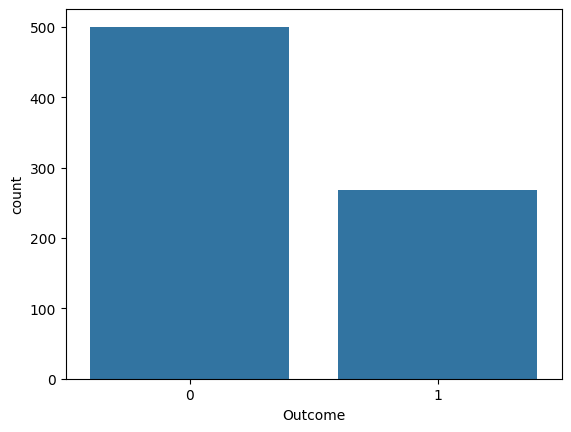

In [74]:
sns.countplot(data=diabetes_data,x='Outcome')

In [27]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [28]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
          F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [75]:
def precision_recall_curve_plot(y_test , pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출. 
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)
    
    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
    
    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    
    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()
    

**Logistic Regression으로 학습 및 예측 수행**

In [30]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state=156)

# 로지스틱 회귀로 학습, 예측 및 평가 수행
lr_clf = LogisticRegression(solver="liblinear")

lr_clf.fit(X_train,y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:,1]

get_clf_eval(y_test,pred,pred_proba)

오차 행렬
[[87 13]
 [22 32]]
정확도: 0.7727, 정밀도: 0.7111, 재현율: 0.5926,          F1: 0.6465, AUC:0.8083


/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: Runtim

/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


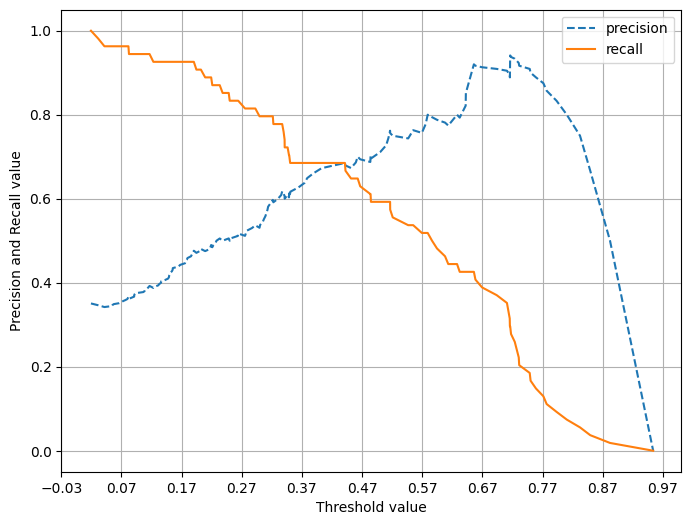

In [32]:
pred_proba_c1 = lr_clf.predict_proba(X_test)[:,1]
precision_recall_curve_plot(y_test, pred_proba_c1)

**각 피처들의 값 4분위 분포 확인**

In [40]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [54]:
min_values = diabetes_data.describe().loc['min']
zero_min_columns = min_values[min_values == 0].index.tolist()
zero_min_columns = zero_min_columns[:-1]

**Glucose 분포도**

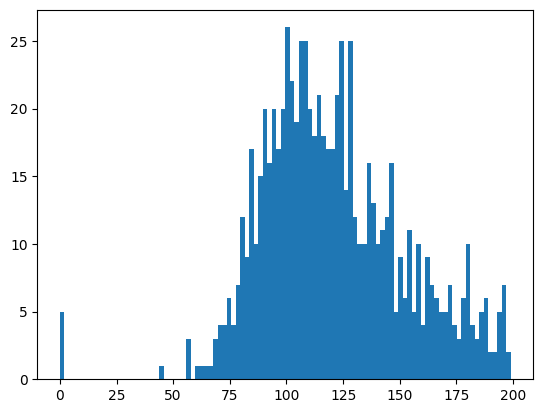

In [55]:
plt.hist(diabetes_data['Glucose'],bins=100)
plt.show()

**0값이 있는 피처들에서 0값의 데이터 건수와 퍼센트 계산**

In [62]:
zero_features = zero_min_columns

total_count = diabetes_data['Glucose'].count()

for feature in zero_features :
    zero_count = diabetes_data[diabetes_data[feature] == 0][feature].count()
    print('{0} 건수는 {1}, 퍼센트는 {2:.2f}%'.format(feature, zero_count, 100*zero_count/total_count))

Pregnancies 건수는 0, 퍼센트는 0.00%
Glucose 건수는 0, 퍼센트는 0.00%
BloodPressure 건수는 0, 퍼센트는 0.00%
SkinThickness 건수는 0, 퍼센트는 0.00%
Insulin 건수는 0, 퍼센트는 0.00%
BMI 건수는 0, 퍼센트는 0.00%


**0값을 평균값으로 대체**

In [60]:
diabetes_data[zero_features].mean()

Pregnancies        8.468979
Glucose          121.102816
BloodPressure     70.563464
SkinThickness     29.992598
Insulin           95.379198
BMI               32.450805
dtype: float64

In [61]:
diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, diabetes_data[zero_features].mean())

In [67]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:,-1]

scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaler,y,test_size=0.2,random_state=156, stratify=y)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train,y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test,pred,pred_proba)




오차 행렬
[[87 13]
 [20 34]]
정확도: 0.7857, 정밀도: 0.7234, 재현율: 0.6296,          F1: 0.6733, AUC:0.8063


/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: Runtim

**분류결정 임곗값을 변경하면서 성능 측정**

In [68]:
from sklearn.preprocessing import Binarizer

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds) :
    for custom_threshold in thresholds :
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값 : ', custom_threshold)
        get_clf_eval(y_test,custom_predict,pred_proba_c1)
    

In [ ]:
thresholds = [0.3, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)

임곗값 :  0.3
오차 행렬
[[69 31]
 [11 43]]
정확도: 0.7273, 정밀도: 0.5811, 재현율: 0.7963,          F1: 0.6719, AUC:0.8063
임곗값 :  0.33
오차 행렬
[[73 27]
 [15 39]]
정확도: 0.7273, 정밀도: 0.5909, 재현율: 0.7222,          F1: 0.6500, AUC:0.8063
임곗값 :  0.36
오차 행렬
[[75 25]
 [19 35]]
정확도: 0.7143, 정밀도: 0.5833, 재현율: 0.6481,          F1: 0.6140, AUC:0.8063
임곗값 :  0.39
오차 행렬
[[78 22]
 [20 34]]
정확도: 0.7273, 정밀도: 0.6071, 재현율: 0.6296,          F1: 0.6182, AUC:0.8063
임곗값 :  0.42
오차 행렬
[[80 20]
 [20 34]]
정확도: 0.7403, 정밀도: 0.6296, 재현율: 0.6296,          F1: 0.6296, AUC:0.8063
임곗값 :  0.45
오차 행렬
[[84 16]
 [20 34]]
정확도: 0.7662, 정밀도: 0.6800, 재현율: 0.6296,          F1: 0.6538, AUC:0.8063
임곗값 :  0.48
오차 행렬
[[86 14]
 [20 34]]
정확도: 0.7792, 정밀도: 0.7083, 재현율: 0.6296,          F1: 0.6667, AUC:0.8063
임곗값 :  0.5
오차 행렬
[[87 13]
 [20 34]]
정확도: 0.7857, 정밀도: 0.7234, 재현율: 0.6296,          F1: 0.6733, AUC:0.8063


/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/songbeom/PythonWorkSpace/machineLearning/venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [72]:
binarizer = Binarizer(threshold=0.48)

pred_th_048 = binarizer.fit_transform(pred_proba[:, 1].reshape(-1,1))

get_clf_eval(y_test,pred_th_048,pred_proba[:, 1])


오차 행렬
[[86 14]
 [20 34]]
정확도: 0.7792, 정밀도: 0.7083, 재현율: 0.6296,          F1: 0.6667, AUC:0.8063
